In [1]:
%load_ext autoreload
%autoreload 2

import sys, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
import wandb
import torchvision

sys.path.append(os.path.join(os.getcwd(), '../symlie'))
sys.path.append(os.path.join(os.getcwd(), '../'))
sys.path.append(os.path.join(os.getcwd(), '../sympdee/sympde/viz'))

from sympdee.sympde.viz.general_plots import imshows, plot_vals, simple_imshow, savefig, simple_imshow

# from symlie.misc.utils_results import get_and_check_Ps
# from symlie.misc.wandb import update_results_df, get_inspect_df
# from symlie.model.setup import load_P_pred
# from symlie.model.networks.linear import LinearP
# from symlie.model.networks.implicit import LinearImplicit
# from symlie.misc.viz import plot2d

from symlie.model.networks.mlp import CombiMLP
from symlie.model.learner import CombiLearner
from symlie.run import parse_options, main, process_args
from symlie.misc.viz import wb_plot_pred

/Users/elias/anaconda3/envs/sympde/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [24]:
## Train Sine 1D

args = parse_options(notebook=True)

args.tags = ['visualisations', 'train']
args.forward_type = 'train'
args.bias = True

args.y_low = 1
args.y_high = 3
args.noise_std = 0.5
args.grid_size = (1, 7)
args.eps_mult = [0., 0., 1.,  0.]
args.data_dir = '../data/sine1d'
args.net = 'CombiTrain'

args.seed = 1
args.n_train = 1000
args.lr = 0.01
args.implicit_layer_dims = [2, 2]
args.vanilla_layer_dims = [7, 7 , 1]
args.grid_sizes = [[[1, 7], [1,  7]], [[1, 1], [1, 7]]]
args.lossweight_y = 1.
args.lossweight_o = 1.

# args.do_return = True
args.logger = None

process_args(args)

# Training
model, trainer, datamodule = main(args)


Seed set to 1
/Users/elias/anaconda3/envs/sympde/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:187: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.


Overwriting max_epochs = 50 to 200
implicit_layer_dims <class 'list'> [2, 2]
implicit_layer_dims <class 'list'> [[56, 56], [8, 8]]
Init rng
Running without logging
Configuring solo optimizer
Print parameters in configure_optimizers
net.implicit_layers.0.implicit_layer.0.weight True
net.implicit_layers.0.implicit_layer.0.bias True
net.implicit_layers.1.implicit_layer.0.weight True
net.implicit_layers.1.implicit_layer.0.bias True
net.vanilla_layers.0.weight True
net.vanilla_layers.0.bias True
net.vanilla_layers.1.weight True
net.vanilla_layers.1.bias True

Testing DataLoader 0: 100%|██████████| 63/63 [00:00<00:00, 354.18it/s]
No logger, skipping logging


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_loss         │    0.07410873472690582    │
│       test_loss_o0        │   0.002312137046828866    │
│       test_loss_o1        │   0.0009747018339112401   │
│        test_loss_y        │    0.07082188129425049    │
└───────────────────────────┴───────────────────────────┘

In [2]:
## Train O5 synthetic

args = parse_options(notebook=True)

args.tags = ['visualisations', 'train']
args.forward_type = 'train'
args.bias = True

args.grid_size = (1, 10)
args.eps_mult = [0., 0., 0.,  0.]
args.data_dir = '../data/o5synth'
args.net = 'CombiTrain'

args.seed = 2
args.n_train = 1000
args.lr = 0.001
args.implicit_layer_dims = [2, 2]
args.vanilla_layer_dims = [10, 10 , 1]
args.grid_sizes = [[[1, 2, 5], [1, 2, 5]], [[1, 1, 1], [1, 2, 5]]]
args.lossweight_y = 0.
args.lossweight_o = 1.

args.do_return = True
args.logger = None

process_args(args)

# Training
model, trainer, datamodule = main(args)


Seed set to 2


Overwriting max_epochs = 50 to 200
implicit_layer_dims <class 'list'> [2, 2]
implicit_layer_dims <class 'list'> [[110, 110], [11, 11]]
Init rng
Running without logging


/Users/elias/anaconda3/envs/sympde/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:187: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
/Users/elias/EliasMBA/Projects/Uni/SymPDE/notebooks_symlie/../symlie/data/dataset.py:64: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:3618.)
  self.y = torch.stack([self.y*(1+y_range_i) for y_range_i in range(args.y_multi)]).T


In [18]:
x = datamodule.val_dataloader().dataset[:20][0]
batch_size = x.shape[0]

In [13]:
from symlie.data.transforms import RandomPermute

In [14]:
# torch random number generator
rng = torch.Generator().manual_seed(1)

In [24]:
x_reshaped

tensor([[[[-0.7688, -0.3694,  1.0502, -0.6031,  1.6914],
          [ 0.5826,  0.3054,  0.3127,  1.1412,  0.5150]]],


        [[[ 0.0936,  0.4051, -0.2562,  2.3282, -0.5275],
          [-1.2686, -0.9779, -0.1081,  2.2774,  0.3499]]],


        [[[-0.1074,  0.7048, -0.0368,  0.0389,  0.0935],
          [-0.1814, -1.5509,  0.3409,  0.2392,  0.2338]]],


        [[[-1.3752, -0.5947, -0.4751,  1.8003,  0.4043],
          [-0.9478,  0.9459,  0.7595, -0.2644,  0.1293]]],


        [[[ 2.1379, -1.1000, -1.0338,  0.9080,  0.3851],
          [ 0.3625,  2.0792, -0.0366, -1.3980, -0.2595]]],


        [[[ 0.7195, -0.4342, -0.8583,  0.0510, -0.7427],
          [-1.7156, -0.0735, -2.1927,  1.3391, -0.1036]]],


        [[[ 0.1823, -1.0619,  0.2473,  0.2630, -1.8849],
          [ 1.3894,  0.4533,  0.6850, -1.8343, -0.5317]]],


        [[[ 1.5177, -1.0326,  0.6880,  0.6079, -0.1649],
          [ 0.2488, -0.8598, -0.7385,  0.5895, -0.5453]]],


        [[[-1.8654,  0.1705, -0.4951,  0.3217,  1.7450],

In [22]:
permute = RandomPermute(dim = 3)

shape = (1, 2, 5)
x_reshaped = x.reshape(batch_size, *shape)
x_permuted = permute(x_reshaped, rng)

x_permuted

tensor([[[[-0.6031,  1.0502,  1.6914, -0.3694, -0.7688],
          [ 1.1412,  0.3127,  0.5150,  0.3054,  0.5826]]],


        [[[ 2.3282, -0.2562, -0.5275,  0.4051,  0.0936],
          [ 2.2774, -0.1081,  0.3499, -0.9779, -1.2686]]],


        [[[ 0.0389, -0.0368,  0.0935,  0.7048, -0.1074],
          [ 0.2392,  0.3409,  0.2338, -1.5509, -0.1814]]],


        [[[ 1.8003, -0.4751,  0.4043, -0.5947, -1.3752],
          [-0.2644,  0.7595,  0.1293,  0.9459, -0.9478]]],


        [[[ 0.9080, -1.0338,  0.3851, -1.1000,  2.1379],
          [-1.3980, -0.0366, -0.2595,  2.0792,  0.3625]]],


        [[[ 0.0510, -0.8583, -0.7427, -0.4342,  0.7195],
          [ 1.3391, -2.1927, -0.1036, -0.0735, -1.7156]]],


        [[[ 0.2630,  0.2473, -1.8849, -1.0619,  0.1823],
          [-1.8343,  0.6850, -0.5317,  0.4533,  1.3894]]],


        [[[ 0.6079,  0.6880, -0.1649, -1.0326,  1.5177],
          [ 0.5895, -0.7385, -0.5453, -0.8598,  0.2488]]],


        [[[ 0.3217, -0.4951,  1.7450,  0.1705, -1.8654],

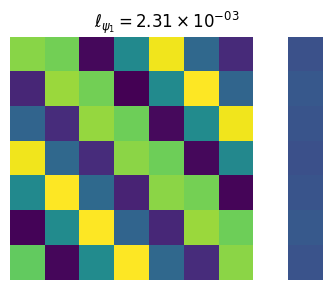

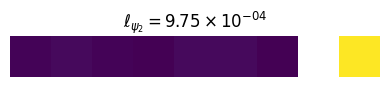

In [26]:
for layer_idx in range(len(model.net.implicit_layers)):
    w, b = model.net.implicit_layers[layer_idx](
        w = model.net.vanilla_layers[layer_idx].weight.data.clone(), 
        b = model.net.vanilla_layers[layer_idx].bias.data.clone() if args.bias else None
    )

    test_loss = f"{trainer.callback_metrics[f'test_loss_o{layer_idx}'].item():.2e}"
    base, exp = test_loss.split('e')

    fig = wb_plot_pred(w, b, colorbar = False, set_axis_off=True, title = rf"$\ell_{{\psi_{layer_idx+1}}} = {base} \times 10^{{ {exp} }}$")
    savefig(fig, f"train_{args.data_dir.split('/')[-1]}_{layer_idx}", '5-experiments', bbox_inches = 'tight')
    # break